# 04 · Business Insights & Segment Profiling

**Input:** `data/processed/final_segmented_dataset.csv`  
**Purpose:** Deep-dive analysis of each buyer segment for the research paper and Parcl business strategy.

This notebook covers:
- Full segment profiles
- Geographic distribution per segment
- Referral channel effectiveness
- Investment vs Home buyer breakdown
- Financing patterns
- Actionable recommendations per segment

## 1 · Imports & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/processed/final_segmented_dataset.csv')

SEGMENT_ORDER = ['Budget Residential Buyers', 'Mainstream Residential Buyers', 'Premium Investors']
COLORS        = {'Budget Residential Buyers': '#3498db',
                 'Mainstream Residential Buyers': '#2ecc71',
                 'Premium Investors': '#e74c3c'}

print('Shape:', df.shape)
print('Segments:', df['Buyer_Segment'].value_counts().to_dict())

Shape: (7305, 20)
Segments: {'Budget Residential Buyers': 3536, 'Premium Investors': 2701, 'Mainstream Residential Buyers': 1068}


## 2 · Segment Overview

In [2]:
# Full numeric profile per segment
profile_cols = ['sale_price', 'floor_area_sqft', 'price_per_sqft',
                'investment_score', 'satisfaction_score', 'age', 'loan_indicator']

segment_profile = df.groupby('Buyer_Segment')[profile_cols].mean().round(2).loc[SEGMENT_ORDER]
print('Segment Mean Profiles:')
segment_profile

Segment Mean Profiles:


,sale_price,floor_area_sqft,price_per_sqft,investment_score,satisfaction_score,age,loan_indicator
Buyer_Segment,,,,,,,
Budget Residential Buyers,247228.95,833.89,297.89,5.29,2.82,56.21,0.37
Mainstream Residential Buyers,368494.22,1172.19,314.19,6.73,3.04,56.60,0.38
Premium Investors,463901.36,1531.12,303.66,8.00,3.37,56.65,0.36


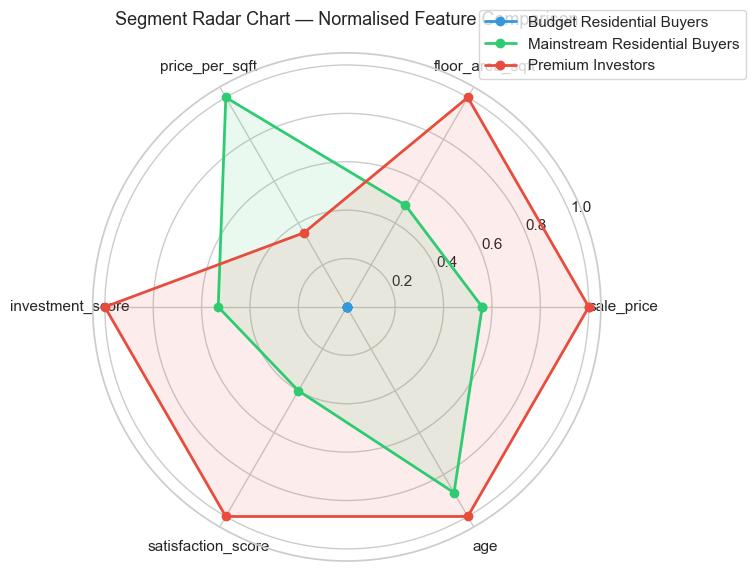

In [3]:
# Radar/spider chart for segment comparison
from matplotlib.patches import FancyArrowPatch

metrics     = ['sale_price', 'floor_area_sqft', 'price_per_sqft', 'investment_score', 'satisfaction_score', 'age']
norm_profile = segment_profile[metrics].copy()
norm_profile = (norm_profile - norm_profile.min()) / (norm_profile.max() - norm_profile.min())

angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for seg in SEGMENT_ORDER:
    values = norm_profile.loc[seg].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=seg, color=COLORS[seg])
    ax.fill(angles, values, alpha=0.1, color=COLORS[seg])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=11)
ax.set_title('Segment Radar Chart — Normalised Feature Comparison', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## 3 · Geographic Distribution by Segment

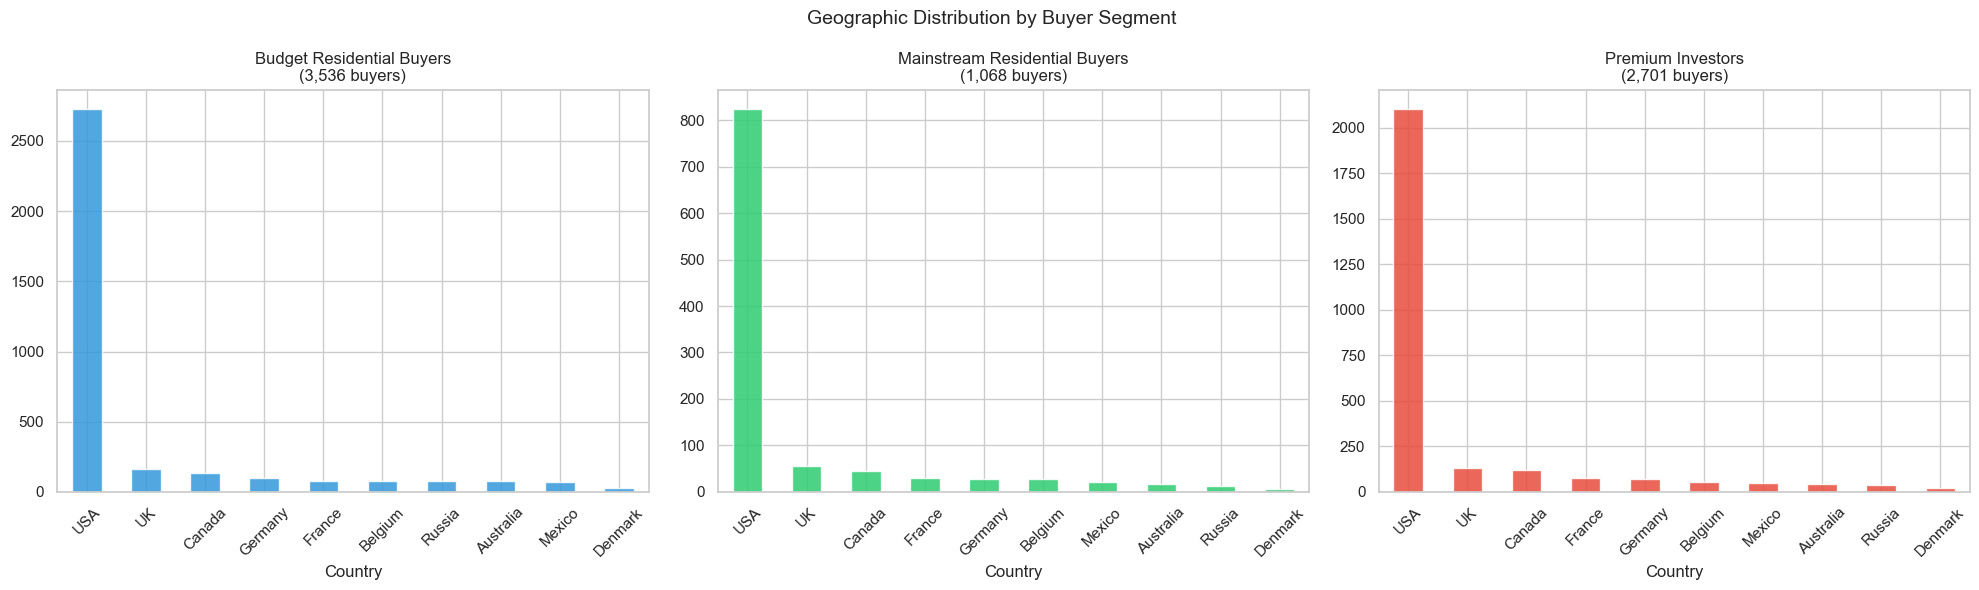

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, seg in enumerate(SEGMENT_ORDER):
    seg_df = df[df['Buyer_Segment'] == seg]
    country_counts = seg_df['country'].value_counts()
    country_counts.plot(kind='bar', ax=axes[i], color=COLORS[seg], alpha=0.85)
    axes[i].set_title(f'{seg}\n({len(seg_df):,} buyers)')
    axes[i].set_xlabel('Country')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Geographic Distribution by Buyer Segment', fontsize=14)
plt.tight_layout()
plt.show()

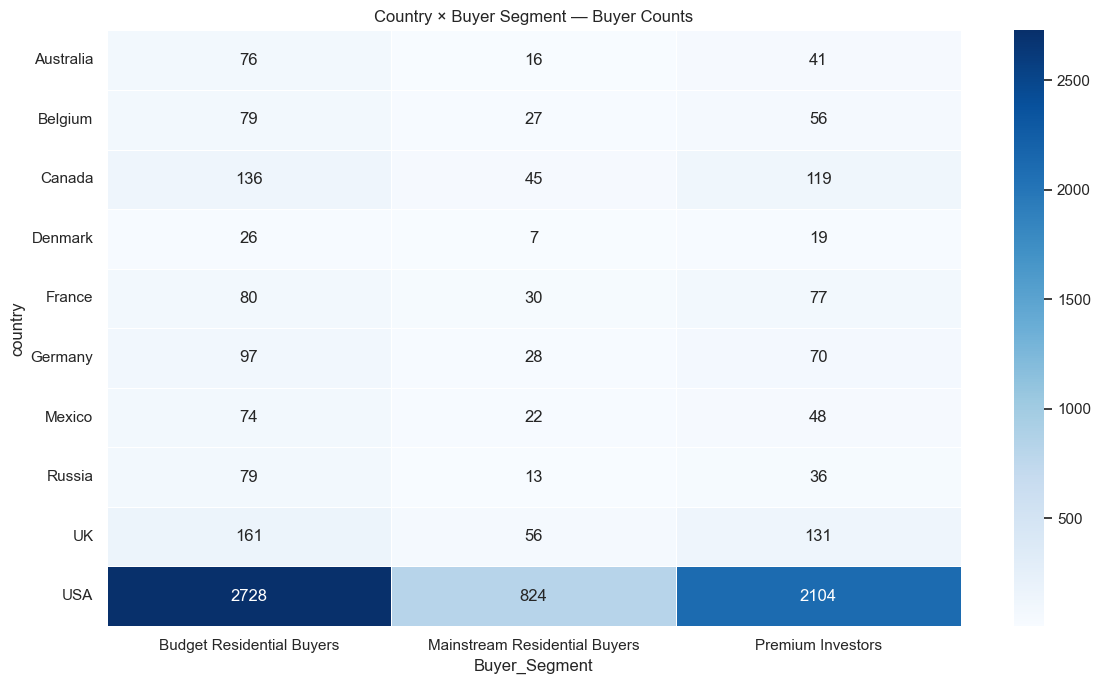

In [5]:
# Country × Segment heatmap
country_seg = pd.crosstab(df['country'], df['Buyer_Segment'])[SEGMENT_ORDER]

plt.figure(figsize=(12, 7))
sns.heatmap(country_seg, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Country × Buyer Segment — Buyer Counts')
plt.tight_layout()
plt.show()

## 4 · Investment Behaviour Analysis

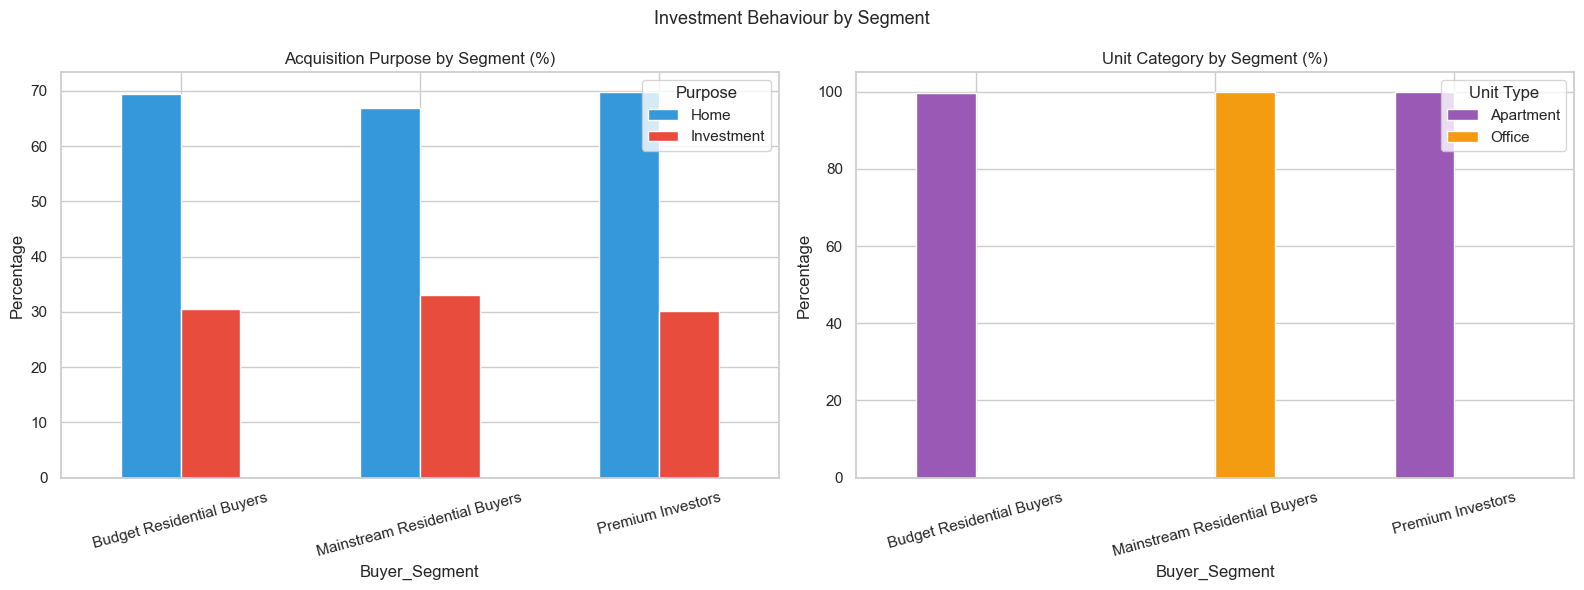

In [6]:
# Acquisition purpose breakdown per segment
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

purpose_pct = pd.crosstab(df['Buyer_Segment'], df['acquisition_purpose'],
                           normalize='index').loc[SEGMENT_ORDER] * 100
purpose_pct.plot(kind='bar', ax=axes[0], color=['#3498db','#e74c3c'])
axes[0].set_title('Acquisition Purpose by Segment (%)')
axes[0].set_ylabel('Percentage')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Purpose')

# Unit category (Apartment vs Office)
unit_pct = pd.crosstab(df['Buyer_Segment'], df['unit_category'],
                        normalize='index').loc[SEGMENT_ORDER] * 100
unit_pct.plot(kind='bar', ax=axes[1], color=['#9b59b6','#f39c12'])
axes[1].set_title('Unit Category by Segment (%)')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Unit Type')

plt.suptitle('Investment Behaviour by Segment', fontsize=13)
plt.tight_layout()
plt.show()

## 5 · Financing Patterns

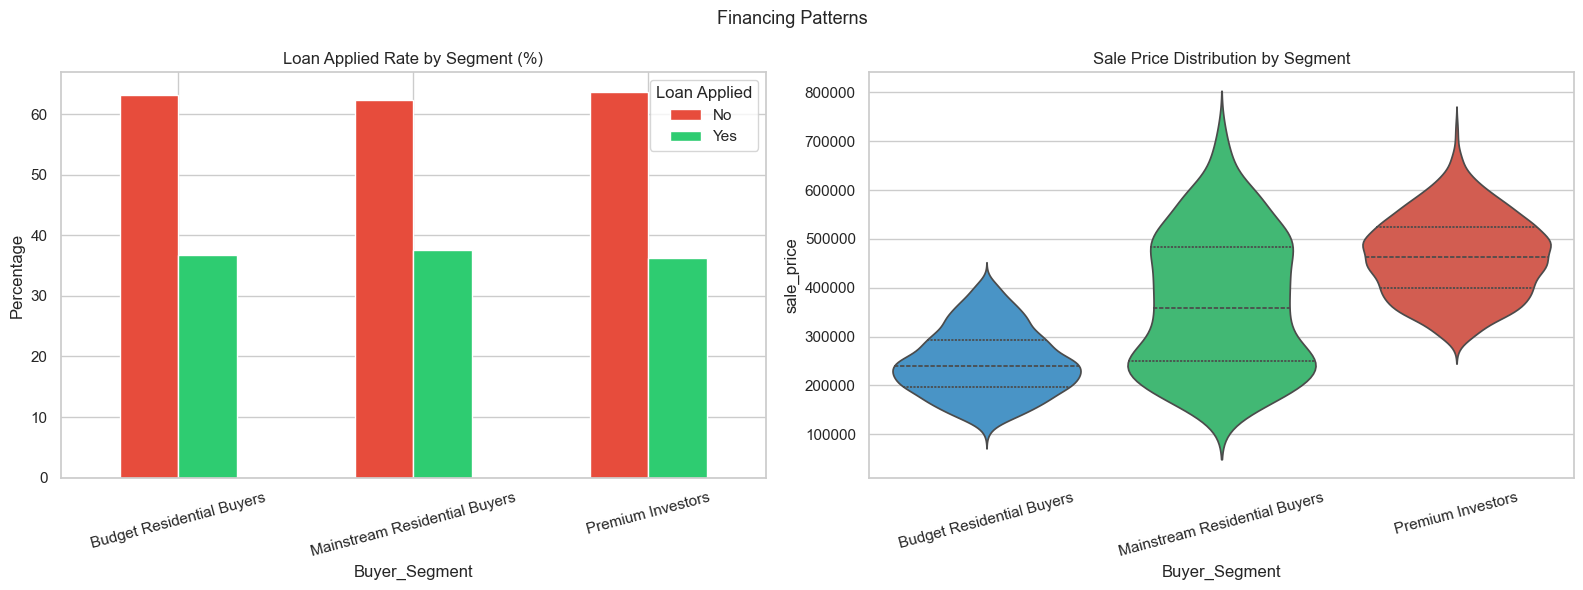

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loan applied rate
loan_pct = pd.crosstab(df['Buyer_Segment'], df['loan_applied'],
                        normalize='index').loc[SEGMENT_ORDER] * 100
loan_pct.plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'])
axes[0].set_title('Loan Applied Rate by Segment (%)')
axes[0].set_ylabel('Percentage')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Loan Applied')

# Sale price distribution per segment
sns.violinplot(data=df, x='Buyer_Segment', y='sale_price',
               order=SEGMENT_ORDER, palette=COLORS, ax=axes[1], inner='quartile')
axes[1].set_title('Sale Price Distribution by Segment')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Financing Patterns', fontsize=13)
plt.tight_layout()
plt.show()

## 6 · Referral Channel Effectiveness

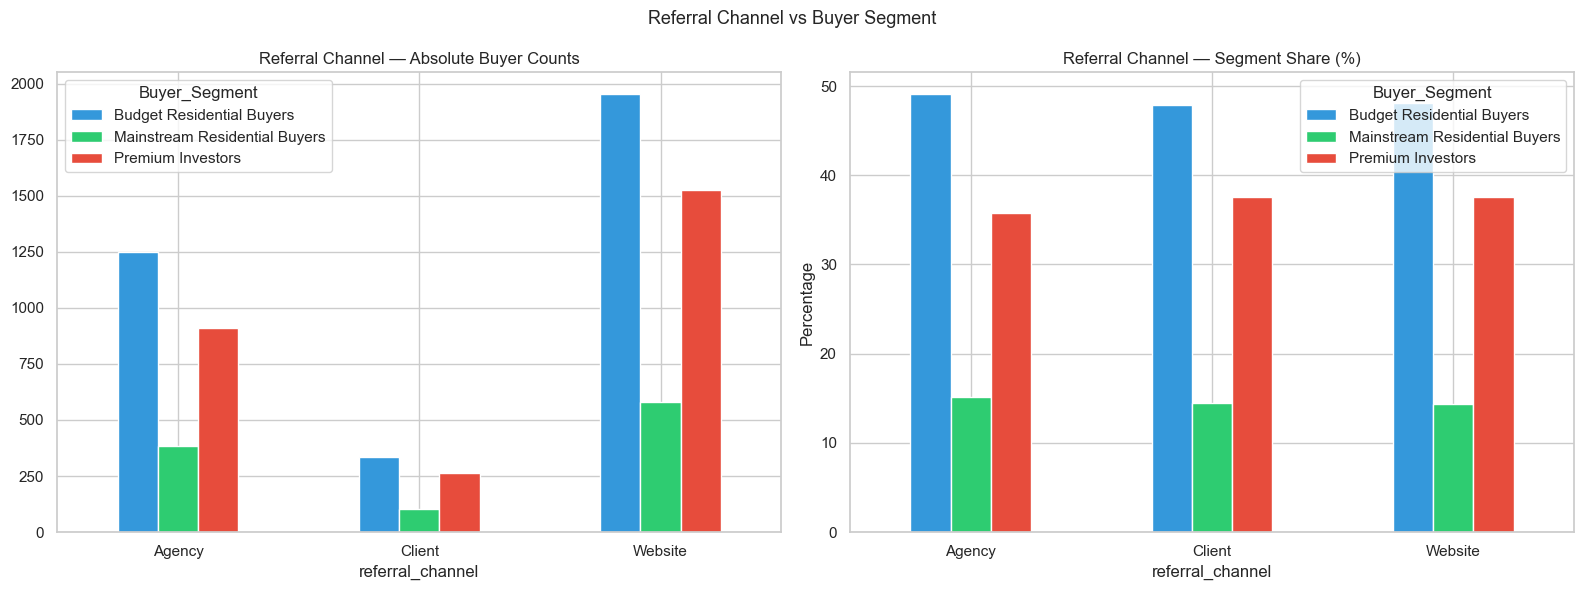

In [8]:
ref_seg = pd.crosstab(df['referral_channel'], df['Buyer_Segment'])[SEGMENT_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ref_seg.plot(kind='bar', ax=axes[0], color=[COLORS[s] for s in SEGMENT_ORDER])
axes[0].set_title('Referral Channel — Absolute Buyer Counts')
axes[0].tick_params(axis='x', rotation=0)

ref_seg_pct = ref_seg.div(ref_seg.sum(axis=1), axis=0) * 100
ref_seg_pct.plot(kind='bar', ax=axes[1], color=[COLORS[s] for s in SEGMENT_ORDER])
axes[1].set_title('Referral Channel — Segment Share (%)')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Referral Channel vs Buyer Segment', fontsize=13)
plt.tight_layout()
plt.show()

## 7 · Satisfaction Analysis

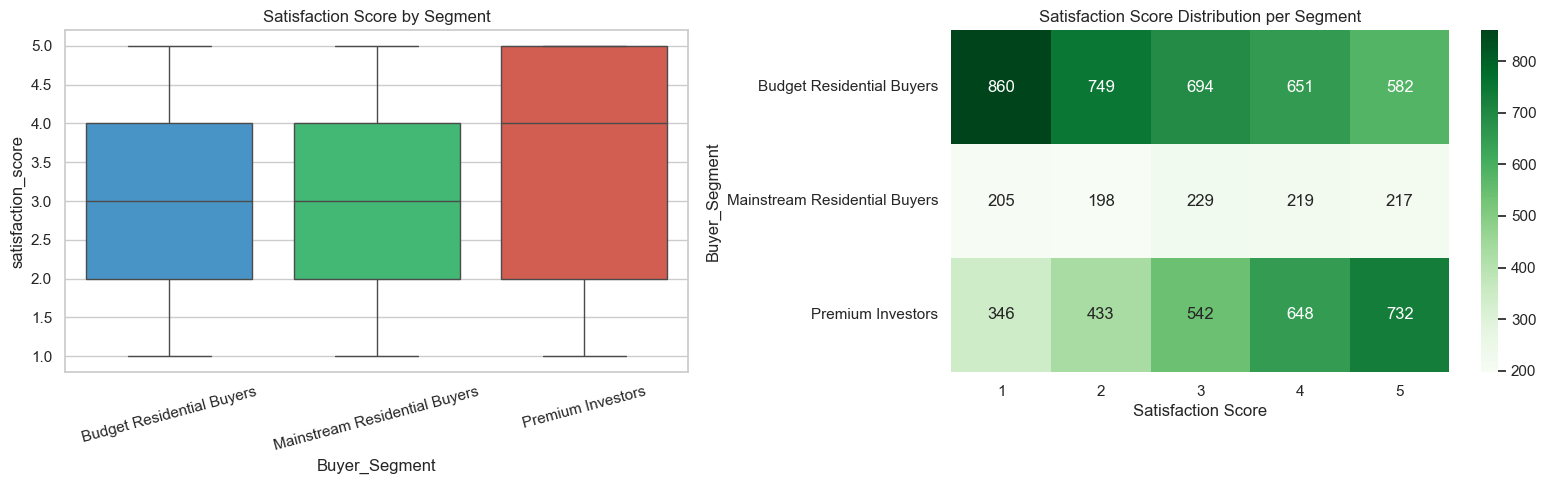

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x='Buyer_Segment', y='satisfaction_score',
            order=SEGMENT_ORDER, palette=COLORS, ax=axes[0])
axes[0].set_title('Satisfaction Score by Segment')
axes[0].tick_params(axis='x', rotation=15)

# Satisfaction score distribution heatmap per segment
sat_seg = pd.crosstab(df['Buyer_Segment'], df['satisfaction_score']).loc[SEGMENT_ORDER]
sns.heatmap(sat_seg, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Satisfaction Score Distribution per Segment')
axes[1].set_xlabel('Satisfaction Score')

plt.tight_layout()
plt.show()

## 8 · Key Business Insights & Recommendations

In [10]:
print('='*65)
print('BUSINESS INSIGHTS — PARCL BUYER SEGMENTATION')
print('='*65)

for seg in SEGMENT_ORDER:
    seg_df = df[df['Buyer_Segment'] == seg]
    print(f'\n── {seg.upper()} ──')
    print(f'  Size             : {len(seg_df):,} buyers ({len(seg_df)/len(df)*100:.1f}%)')
    print(f'  Avg Sale Price   : ${seg_df["sale_price"].mean():,.0f}')
    print(f'  Avg Age          : {seg_df["age"].mean():.1f} years')
    print(f'  Avg Satisfaction : {seg_df["satisfaction_score"].mean():.2f}/5')
    print(f'  Loan Applied (%) : {(seg_df["loan_applied"]=="Yes").mean()*100:.1f}%')
    print(f'  Investment (%)   : {(seg_df["acquisition_purpose"]=="Investment").mean()*100:.1f}%')
    print(f'  Top Country      : {seg_df["country"].value_counts().index[0]}')
    print(f'  Top Channel      : {seg_df["referral_channel"].value_counts().index[0]}')

print('\n' + '='*65)
print('RECOMMENDATIONS')
print('='*65)
print('''
Budget Residential Buyers:
  → Offer mortgage partnership programmes (high loan dependency)
  → Target via Website channel (most effective)
  → Focus on smaller Apartment units
  → Price-sensitive: highlight affordability and value for money

Mainstream Residential Buyers:
  → Mid-tier property recommendations
  → Agency channel most effective for this group
  → Balanced Home/Investment mix — target both use cases
  → Highlight community amenities and lifestyle features

Premium Investors:
  → Exclusive investor briefings and portfolio reports
  → International outreach — diverse geographic origin
  → High satisfaction — leverage for referral programs
  → Offer Office units and large-floor Apartments
  → Premium CRM treatment and dedicated account managers
''')

BUSINESS INSIGHTS — PARCL BUYER SEGMENTATION

── BUDGET RESIDENTIAL BUYERS ──
  Size             : 3,536 buyers (48.4%)
  Avg Sale Price   : $247,229
  Avg Age          : 56.2 years
  Avg Satisfaction : 2.82/5
  Loan Applied (%) : 36.8%
  Investment (%)   : 30.5%
  Top Country      : USA
  Top Channel      : Website

── MAINSTREAM RESIDENTIAL BUYERS ──
  Size             : 1,068 buyers (14.6%)
  Avg Sale Price   : $368,494
  Avg Age          : 56.6 years
  Avg Satisfaction : 3.04/5
  Loan Applied (%) : 37.6%
  Investment (%)   : 33.1%
  Top Country      : USA
  Top Channel      : Website

── PREMIUM INVESTORS ──
  Size             : 2,701 buyers (37.0%)
  Avg Sale Price   : $463,901
  Avg Age          : 56.6 years
  Avg Satisfaction : 3.37/5
  Loan Applied (%) : 36.3%
  Investment (%)   : 30.1%
  Top Country      : USA
  Top Channel      : Website

RECOMMENDATIONS

Budget Residential Buyers:
  → Offer mortgage partnership programmes (high loan dependency)
  → Target via Website channel

In [11]:
# Save insights summary
insights = []
for seg in SEGMENT_ORDER:
    seg_df = df[df['Buyer_Segment'] == seg]
    insights.append({
        'Segment'           : seg,
        'Count'             : len(seg_df),
        'Pct_Total'         : round(len(seg_df)/len(df)*100, 1),
        'Avg_Sale_Price'    : round(seg_df['sale_price'].mean(), 0),
        'Avg_Age'           : round(seg_df['age'].mean(), 1),
        'Avg_Satisfaction'  : round(seg_df['satisfaction_score'].mean(), 2),
        'Loan_Rate_Pct'     : round((seg_df['loan_applied']=='Yes').mean()*100, 1),
        'Investment_Pct'    : round((seg_df['acquisition_purpose']=='Investment').mean()*100, 1),
        'Top_Country'       : seg_df['country'].value_counts().index[0],
        'Top_Referral'      : seg_df['referral_channel'].value_counts().index[0],
    })

insights_df = pd.DataFrame(insights)
insights_df.to_csv('../data/processed/segment_insights.csv', index=False)
print('segment_insights.csv saved')
insights_df

segment_insights.csv saved


,Segment,Count,Pct_Total,Avg_Sale_Price,Avg_Age,Avg_Satisfaction,Loan_Rate_Pct,Investment_Pct,Top_Country,Top_Referral
0,Budget Residential Buyers,3536,48.4,247229.0,56.2,2.82,36.8,30.5,USA,Website
1,Mainstream Residential Buyers,1068,14.6,368494.0,56.6,3.04,37.6,33.1,USA,Website
2,Premium Investors,2701,37.0,463901.0,56.6,3.37,36.3,30.1,USA,Website
